# Agentic AI Tutorial: Harnessing LLMs, Building Tool-Using Agents, and RAG

In the previous tutorial, we examined the Transformer architecture and implemented a small sequence-to-sequence model. In this tutorial, we move from the internal architecture of a language model to the larger application built around it.

A pretrained language model can generate text, but a useful application usually needs additional components. The application must decide what information the model receives, what output format is expected, which outputs are accepted, and whether an external tool should be used.

We will build these ideas in the following order:

1. **Harness an LLM** with prompting, decoding, structured output, validation, and retries.
2. **Build a tool-using agent** that chooses between a calculator, web search, and weather.
3. **Explore RAG** interactively using RAG-O-Matic.

<table>
<tr>
<td align="center"><b>Language model</b><br>Generates text</td>
<td align="center">→</td>
<td align="center"><b>Harness</b><br>Controls prompts and outputs</td>
<td align="center">→</td>
<td align="center"><b>Tool-using agent</b><br>Selects external functions</td>
<td align="center">→</td>
<td align="center"><b>RAG</b><br>Adds external knowledge</td>
</tr>
</table>

The agent is implemented directly in Python. RAG is explored separately as another way to extend an LLM application. A larger system could later expose a RAG retriever as one of the agent's tools.

## 1. Environment setup

The notebook uses a small instruction-tuned Qwen model from Hugging Face. A T4 GPU is recommended for faster generation.

The timeout setting below is useful on slow or intermittent Colab connections. The Xet setting is included as a troubleshooting option and should normally remain commented out.

### What runs locally and what uses the network?

Most of the notebook runs locally after the model has been downloaded.

| Component | What it does | Network required? |
|---|---|---|
| Qwen model | Generates text and tool decisions | Only for the initial download |
| Calculator | Evaluates arithmetic | No |
| TF–IDF retriever | Searches the local knowledge base | No |
| Agent loop | Stores state and calls local tools | No |
| Web search | Retrieves public search results | Yes |
| Weather tool | Calls a public weather endpoint | Yes |

The web and weather tools are included to show how an agent can interact with external services. The RAG and calculator demonstrations remain reproducible without them.

In [1]:
# Install the libraries used in the tutorial.
%pip -q install -U "transformers>=5,<6" accelerate ddgs requests matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 47.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
import os

# Allow more time for model files to download from Hugging Face.
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"

# Uncomment this only if the Hugging Face download repeatedly hangs.
# os.environ["HF_HUB_DISABLE_XET"] = "1"

In [3]:
# Standard-library imports.
import json
import re
from typing import Any

# Third-party imports.
import matplotlib.pyplot as plt
import numpy as np
import requests
import torch

# Fix random seeds so sampled examples are easier to reproduce.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Check whether Colab has provided a GPU.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


## 2. Load an instruction-tuned language model

We use `Qwen/Qwen2.5-0.5B-Instruct`.

The model is:

- **instruction-tuned:** it has been trained to respond to user instructions rather than only continue arbitrary text;
- **small:** 0.5 billion parameters keeps the download and loading time suitable for a live notebook;
- **chat-formatted:** it receives messages with roles such as `system` and `user`.

The `pipeline` function handles tokenization, model inference, and decoding. We are using a pretrained model directly; no training or gradient updates occur in this notebook.

In [4]:
from transformers import pipeline

# Use the 0.5B model so that the live demonstration loads quickly.
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

# Load the model on the GPU automatically when one is available.
llm = pipeline(
    task="text-generation",
    model=MODEL_NAME,
    dtype="auto",
    device_map="auto",
)

# Some model configurations still contain the legacy max_length=20 setting.
# This notebook controls output length with max_new_tokens instead.
llm.model.generation_config.max_length = None

print("Loaded:", MODEL_NAME)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-0.5B-Instruct


In [5]:
def ask(
    prompt: str,
    *,
    system: str = "You are a helpful assistant.",
    max_new_tokens: int = 160,
    temperature: float = 0.0,
) -> str:
    """Send one chat prompt to the model and return only its reply."""

    # Chat models receive a list of messages with explicit roles.
    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": prompt},
    ]

    # Temperature 0 uses deterministic greedy decoding.
    do_sample = temperature > 0

    # Use max_new_tokens to limit only the newly generated reply.
    generation_args = {
        "max_new_tokens": max_new_tokens,
        "do_sample": do_sample,
    }

    # Temperature is relevant only when sampling is enabled.
    if do_sample:
        generation_args["temperature"] = temperature

    # Generate the assistant message.
    output = llm(messages, **generation_args)

    # The pipeline returns the conversation; the final item is the new reply.
    return output[0]["generated_text"][-1]["content"].strip()

In [6]:
# Test the model wrapper.
print(
    ask(
        "Explain the difference between a language model and an agent in one sentence.",
        max_new_tokens=80,
    )
)

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


A language model is a computer program that simulates human-like behavior by learning to understand, generate, and respond to natural language input, while an agent is a software or hardware system that performs specific tasks based on predefined rules or instructions.


### Chat messages and roles

A chat model still processes one sequence of tokens internally. The message list is converted into a model-specific text template before tokenization.

| Role | Purpose |
|---|---|
| `system` | Sets overall behavior, rules, or constraints |
| `user` | Contains the current request |
| `assistant` | Represents a previous or newly generated response |

The `ask` wrapper keeps this formatting in one place. Later sections can call `ask(...)` without repeating the pipeline code.

<table>
<tr>
<td align="center"><b>Messages</b><br><code>system</code> + <code>user</code></td>
<td align="center">→</td>
<td align="center"><b>Chat template</b><br>One token sequence</td>
<td align="center">→</td>
<td align="center"><b>Model</b><br>Next-token prediction</td>
<td align="center">→</td>
<td align="center"><b>Assistant reply</b></td>
</tr>
</table>

## 3. Harnessing an LLM

A language model is probabilistic. The surrounding application controls:

- the instructions sent to the model;
- examples included in the prompt;
- decoding settings;
- the required output format;
- how the response is parsed and validated;
- what happens when the response is invalid.

This surrounding application logic is often called the **LLM harness**.

A useful prompt usually contains several distinct pieces:

| Prompt component | Purpose |
|---|---|
| Role | Describes the behavior expected from the model |
| Task | States the operation to perform |
| Context | Supplies information needed for the current request |
| Constraints | Limits what the model may return or use |
| Output format | Defines how another program should read the answer |

The model remains flexible, while the harness makes its behavior easier to use inside a program.

### 3.1 Zero-shot and few-shot prompting

A **zero-shot** prompt describes the task without examples. The model relies on instruction tuning and the wording of the current request.

A **few-shot** prompt includes demonstrations that show the intended mapping from input to output. The examples can clarify:

- which labels are allowed;
- how detailed the response should be;
- what format should be followed;
- how ambiguous cases should be handled.

The model weights do not change in either case. The examples are part of the current context and disappear after the request is complete.

In [7]:
# Zero-shot: describe the task without giving an example.
zero_shot_prompt = """
Classify the support ticket as billing, shipping, account, technical, or other.

Ticket:
The mobile app closes whenever I upload a photo.
"""

print(ask(zero_shot_prompt, max_new_tokens=80))

[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Support Ticket: Technical


In [8]:
# Few-shot: demonstrate the desired mapping and output format.
few_shot_prompt = """
Classify each support ticket.
Return: category | priority | short reason

Example:
Ticket: My package has not arrived after two weeks.
Answer: shipping | high | delivery is substantially delayed

Example:
Ticket: I forgot my password and cannot sign in.
Answer: account | medium | user needs account recovery

Now classify:
Ticket: The mobile app closes whenever I upload a photo.
Answer:
"""

print(ask(few_shot_prompt, max_new_tokens=80))

[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Ticket: The mobile app closes whenever I upload a photo.

Answer: application | low | the app crashes or freezes when users upload photos frequently.


### 3.2 Decoding

At each generation step, the model assigns a score to every possible next token. Decoding determines how the next token is selected from those scores.

- **Greedy decoding** chooses the highest-probability token.
- **Temperature** controls how strongly the model prefers high-probability tokens.
- A low temperature is useful for extraction, classification, JSON, and tool calls.
- A higher temperature can produce more varied responses for brainstorming.

Temperature changes generation, not the model weights. A higher temperature does not make the model more knowledgeable; it only makes lower-probability tokens more likely to be sampled.

In [9]:
prompt = "Suggest one application of RAG in an engineering course."

# Deterministic response.
print("Temperature 0:")
print(ask(prompt, temperature=0.0, max_new_tokens=100))

# More varied response.
print("\nTemperature 0.9:")
print(ask(prompt, temperature=0.9, max_new_tokens=100))

[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temperature 0:


[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


One application of RAG (Resilience Analysis and Gap Analysis) in an engineering course could be to help students understand the importance of identifying and addressing potential risks and gaps in their projects or work environments. By using RAG, students can learn how to identify potential hazards and vulnerabilities that may arise from various sources such as human error, equipment failure, environmental factors, and other external influences. They can also develop strategies for mitigating these risks and gaps, which will help them create more robust and resilient

Temperature 0.9:
One application of RAG (Randomized Experiment Design with Assurance) in an engineering course is to teach students how to design and conduct experiments to evaluate the impact of different variables on outcomes, ensuring that the results are reliable and valid. 

By using RAG, students can learn how to:

1. Randomize participants: Randomizing participants helps ensure that all groups receive similar trea

The following visualization uses a small hypothetical token distribution. It illustrates why low temperature produces a concentrated choice, while high temperature spreads probability across more alternatives.

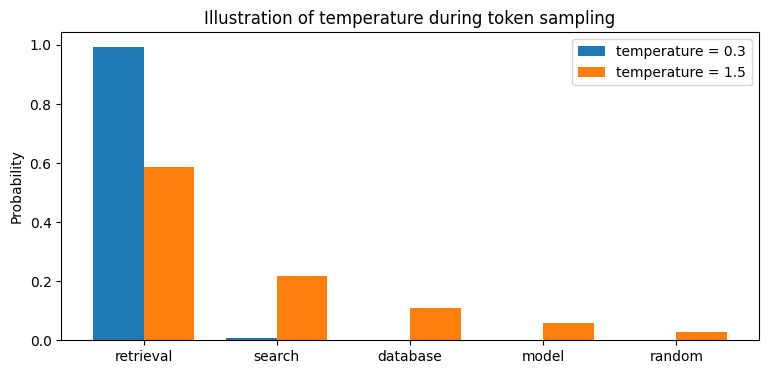

In [10]:
# Hypothetical scores for five possible next tokens.
token_scores = np.array([4.0, 2.5, 1.5, 0.5, -0.5])
token_names = ["retrieval", "search", "database", "model", "random"]


def temperature_softmax(scores: np.ndarray, temperature: float) -> np.ndarray:
    """Convert scores into probabilities at a chosen temperature."""

    # Divide by temperature before applying softmax.
    scaled_scores = scores / temperature

    # Subtract the maximum for numerical stability.
    scaled_scores = scaled_scores - scaled_scores.max()

    # Exponentiate and normalize so probabilities sum to one.
    weights = np.exp(scaled_scores)
    return weights / weights.sum()


# Compare a concentrated and a more varied distribution.
low_temperature = temperature_softmax(token_scores, 0.3)
high_temperature = temperature_softmax(token_scores, 1.5)

# Plot the two distributions side by side.
x = np.arange(len(token_names))
width = 0.38

plt.figure(figsize=(9, 4))
plt.bar(x - width / 2, low_temperature, width, label="temperature = 0.3")
plt.bar(x + width / 2, high_temperature, width, label="temperature = 1.5")
plt.xticks(x, token_names)
plt.ylabel("Probability")
plt.title("Illustration of temperature during token sampling")
plt.legend()
plt.show()

### 3.3 Structured output and validation

Natural-language responses are easy for people to read but difficult for another program to process consistently. A response may contain an explanation, a label, a markdown heading, or a differently worded answer each time.

Structured output gives the response a predictable shape:

```json
{
  "category": "billing",
  "priority": "high",
  "summary": "The customer reports a duplicate charge."
}
```

The process has three separate stages:

<table>
<tr>
<td align="center"><b>Generation</b><br>The model returns text</td>
<td align="center">→</td>
<td align="center"><b>Parsing</b><br>Text becomes a Python object</td>
<td align="center">→</td>
<td align="center"><b>Validation</b><br>The object is checked against application rules</td>
</tr>
</table>

Valid JSON is not automatically valid for the application. A model could return a valid JSON object containing an unknown category, a missing field, or an unsafe tool name.

In [11]:
ticket_prompt = """
Classify the support ticket.

Allowed categories:
billing, shipping, account, technical, other

Allowed priorities:
low, medium, high

Return only one JSON object with these keys:
category, priority, summary

Ticket:
I was charged twice for order 1842 and need the extra charge returned.
"""

# Ask for deterministic structured output.
ticket_text = ask(
    ticket_prompt,
    system="Return valid JSON only. Do not use a markdown code fence.",
    max_new_tokens=120,
)

print(ticket_text)

[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{
  "category": "other",
  "priority": "medium",
  "summary": "Order 1842 charges twice"
}


In [12]:
def parse_json(text: str) -> dict[str, Any]:
    """Parse a JSON object, allowing an optional markdown code fence."""

    # Remove common ```json ... ``` wrappers.
    cleaned = text.strip()
    cleaned = re.sub(r"^```(?:json)?\s*", "", cleaned, flags=re.IGNORECASE)
    cleaned = re.sub(r"\s*```$", "", cleaned)

    # Convert the JSON string into a Python dictionary.
    value = json.loads(cleaned)

    # Reject arrays, strings, and other valid JSON values.
    if not isinstance(value, dict):
        raise ValueError("Expected one JSON object.")

    return value


def validate_ticket(value: dict[str, Any]) -> dict[str, str]:
    """Check that the parsed ticket follows the application schema."""

    # Define the values that the application accepts.
    categories = {"billing", "shipping", "account", "technical", "other"}
    priorities = {"low", "medium", "high"}

    # Read and normalize the three required fields.
    category = str(value.get("category", "")).lower()
    priority = str(value.get("priority", "")).lower()
    summary = str(value.get("summary", "")).strip()

    # Reject unknown labels or an empty summary.
    if category not in categories:
        raise ValueError(f"Invalid category: {category}")
    if priority not in priorities:
        raise ValueError(f"Invalid priority: {priority}")
    if not summary:
        raise ValueError("The summary is empty.")

    # Return a clean object that the rest of the program can trust.
    return {
        "category": category,
        "priority": priority,
        "summary": summary,
    }


# Parse the text, then validate the resulting dictionary.
ticket = validate_ticket(parse_json(ticket_text))
ticket

{'category': 'other',
 'priority': 'medium',
 'summary': 'Order 1842 charges twice'}

### 3.4 One repair attempt

When parsing fails, the application can send the invalid response and the error message back to the model. The model then receives enough information to correct formatting mistakes.

Retries should remain bounded. A model may repeatedly produce invalid output, and an unlimited retry loop can waste time and compute without improving the result.

The implementation below allows one correction attempt. If the repaired response is still invalid, the exception is returned to the caller.

In [13]:
def ask_for_json(prompt: str) -> dict[str, Any]:
    """Request JSON and allow one correction attempt."""

    # First attempt.
    text = ask(
        prompt,
        system="Return one valid JSON object only.",
        max_new_tokens=120,
    )

    try:
        return parse_json(text)
    except (json.JSONDecodeError, ValueError) as error:
        # Ask once more and include the specific parsing error.
        repair_prompt = f"""
{prompt}

Your previous response was invalid:
{text}

Error:
{error}

Return a corrected JSON object only.
"""
        repaired_text = ask(
            repair_prompt,
            system="Return one valid JSON object only.",
            max_new_tokens=120,
        )

        # If this also fails, allow the exception to reach the caller.
        return parse_json(repaired_text)

## 4. Building a tool-using agent

A language model is useful for interpreting natural language and deciding which capability is needed. Ordinary Python functions perform the actual work.

A **tool** is a function that performs one specific task. The `tools` dictionary maps each tool name to its implementation.

The agent loop follows the same basic pattern throughout this section:

```text
ask a question
      ↓
model selects a tool
      ↓
Python calls the tool
      ↓
display the result
```

We build the agent gradually:

1. calculator only;
2. calculator or web search;
3. calculator, web search, or weather.

Each version redefines `tools`, `prompt_template`, and `agent_loop()` to include the newly available capability.

### 4.1 Our first tool: calculator

Let's start by implementing a simple calculator tool. This will help us understand the basic structure of tool-using agents.

The calculator is an ordinary Python function. The language model does not perform the arithmetic itself; it decides whether the calculator should handle the question.


Key concepts:
1. Tool Definition: A function that performs a specific task
2. Tool Registry: A dictionary that maps tool names to their implementations
3. Prompt Engineering: Creating clear instructions for the model
4. Agent Loop: The main decision-making cycle

#### Understanding the Code:
- The `calculator` function uses Python's `eval` to compute mathematical expressions
- The `tools` dictionary serves as our tool registry
- The `prompt_template` provides instructions to the language model
- The `agent_loop` manages the interaction between user, model, and tools

In [14]:
# Tool 1: Calculator
def calculator(query):
    """Evaluate a mathematical expression."""

    try:
        # eval keeps this first demonstration short.
        # Do not pass untrusted text directly to eval in a real application.
        return str(eval(query))
    except Exception as error:
        # Return the error as a tool observation instead of crashing.
        return f"Error: {error}"


# The tool registry maps a tool name to its Python function.
tools = {
    "calculator": calculator,
}


# The model's only responsibility is to select the best tool.
prompt_template = """
You are a tool-routing agent. Pick the single best tool to answer the user's question.
Do NOT answer the question yourself.

Available tools:
- calculator: use this for computing expressions like 5*(3+2) or 12/4

Instructions:
- Reply with only the tool name and nothing else.

Question: {question}
Tool:
"""


def agent_loop():
    """Run an interactive single-tool agent."""

    while True:
        # Read one question from the user.
        question = input("\nAsk me something: ")

        # End the loop when the user types exit or quit.
        if question.lower() in ["exit", "quit"]:
            break

        # Ask the language model which tool should handle the question.
        prompt = prompt_template.format(question=question)
        thought = ask(prompt, max_new_tokens=10)
        print("Thought:", thought)

        if "calculator" in thought.lower():
            # Keep only characters used in basic arithmetic.
            expression = "".join(
                character
                for character in question
                if character.isdigit() or character in "+-*/.()"
            )

            # Call the selected tool.
            result = tools["calculator"](expression)

            print("Action: calculator")
            print("Input:", expression)
            print("Output:", result)
        else:
            print("Final Answer:", thought)

In [15]:
# Start the interactive agent.
# Type exit or quit when you are finished.

# agent_loop()

### Exercise: Understanding the calculator agent

Set `RUN_CALCULATOR_AGENT = True` and try:

- `2*2`
- `3+5*2`
- `sqrt(16)`

Discuss:

1. How does the model decide to use the calculator?
2. What happens when the mathematical expression is invalid?
3. Why does `sqrt(16)` produce a misleading result?

<details>
            <summary><b>Answer to Exercise 1</b></summary>

1. The prompt describes the available tool and asks the model to return only its name. The model is performing **tool routing**, not arithmetic.

2. The calculator catches exceptions and returns an error string. For example, an incomplete expression such as `3+` produces a syntax error observation instead of stopping the notebook.

3. The character filter removes every character that is not a digit or one of `+-*/.()`. Therefore, `sqrt(16)` becomes `(16)`, and the calculator returns `16`. The system has silently changed the user's request instead of understanding it.


</details>

### 4.2 Adding web search

The calculator can answer arithmetic questions, but it cannot look up factual or current information. We now add a DuckDuckGo search tool and let the model choose between two tools.

The model still returns only a tool name. Once a tool is selected, the Python code prepares its input and calls the corresponding function.

In [16]:
from ddgs import DDGS


# Tool 2: Search the public web with DuckDuckGo.
def web_search(query):
    """Return the first DuckDuckGo search result."""

    try:
        # Open a DuckDuckGo search session.
        with DDGS() as ddgs:
            # Request one result to keep the demonstration short.
            results = ddgs.text(query, max_results=1)

            # Return the title and snippet from the first result.
            for result in results:
                return f"{result['title']}: {result['body']}"

        # The search may complete without returning a result.
        return "No results found."

    except Exception as error:
        # Return network or search errors as tool observations.
        return f"Search error: {error}"


# The agent can now choose between two tools.
tools = {
    "calculator": calculator,
    "web_search": web_search,
}


# Examples help the small model distinguish the two tool purposes.
prompt_template = """
You are a tool-routing agent. Pick the single best tool to answer the user's question.
Do NOT answer the question yourself.

Available tools:
- calculator: use for arithmetic such as 5*(3+2) or 12/4
- web_search: use for facts, names, places, or current events

Examples:
Question: What is 12/4?
Tool: calculator

Question: Who won the 2022 World Cup?
Tool: web_search

Question: What is the capital of Japan?
Tool: web_search

Instructions:
- Reply with only the tool name and nothing else.

Question: {question}
Tool:
"""


def agent_loop():
    """Run an interactive agent with calculator and web search."""

    while True:
        # Read one question from the user.
        question = input("\nAsk me something: ")

        # Type exit or quit to end the loop.
        if question.lower() in ["exit", "quit"]:
            break

        # Ask the model which tool should handle the question.
        prompt = prompt_template.format(question=question)
        thought = ask(prompt, max_new_tokens=10)
        print("Thought:", thought)

        if "calculator" in thought.lower():
            # Extract digits and basic arithmetic symbols.
            expression = "".join(
                character
                for character in question
                if character.isdigit() or character in "+-*/.()"
            )

            # Execute the calculator.
            result = tools["calculator"](expression)

            print("Action: calculator")
            print("Input:", expression)
            print("Output:", result)

        elif "web_search" in thought.lower():
            # Use the complete question as the search query.
            result = tools["web_search"](question)

            print("Action: web_search")
            print("Input:", question)
            print("Output:", result)

        else:
            # Show any unexpected routing response.
            print("Final Answer:", thought)

In [17]:
# agent_loop()

### Exercise 2: Testing web-search integration

Try the enhanced agent with some queries:

- `What is the capital of Canada?`
- `What is 12/4?`
- `When is Canada day?`

Discuss:

1. How does the model choose between the calculator and web search?
2. How reliable is one search-result snippet?
3. What are the limitations of returning only one result?
4. How could the routing prompt be improved?

<details>
            <summary><b>Answer to Exercise 2</b></summary>

1. The model compares the question with the tool descriptions and few-shot examples in the prompt. Arithmetic questions resemble the calculator example, while factual or current questions resemble the web-search examples.

2. A search snippet is useful for a quick demonstration, but it is not guaranteed to be correct, complete, or current. It may omit important context or come from an unreliable page.

3. The top-ranked result may not be the best source. Returning only one result prevents comparison across sources and may miss relevant information.

4. The prompt could include more examples, clearer boundaries between tool purposes, or a constrained output such as a multiple-choice letter. The output should still be checked before execution.

</details>

### 4.3 Adding weather information

Weather is current information, so the web-search tool could sometimes answer a weather question. A dedicated weather tool is more direct and returns a predictable one-line response.

With three tools, free-form tool names become less reliable for a small model. We therefore constrain the model to choose one letter:

- `A` for calculator;
- `B` for web search;
- `C` for weather.

This is still the same agent loop. Only the routing prompt and selection logic have changed.

In [18]:
# Tool 3: Retrieve a one-line weather summary.
def get_weather(city):
    """Return current weather from wttr.in."""

    try:
        # wttr.in returns a compact summary when format=3 is used.
        url = f"https://wttr.in/{city}?format=3"

        # Use a timeout so the request cannot wait indefinitely.
        response = requests.get(url, timeout=12)

        # Return the weather text when the request succeeds.
        if response.status_code == 200:
            return response.text.strip()

        return f"Error: Could not get weather for {city}"

    except Exception as error:
        # Return connection errors as tool observations.
        return f"Weather lookup failed: {error}"


# The agent can now choose among three tools.
tools = {
    "calculator": calculator,
    "web_search": web_search,
    "get_weather": get_weather,
}


# Multiple choice gives the 0.5B model a smaller output space.
prompt_template = """
Question: {question}

Which tool is needed to answer this question?

A) calculator - for arithmetic such as 5*(3+2) or 12/4
B) web_search - for facts, names, places, or current events
C) get_weather - for current weather in a city

Answer with one letter only: A, B, or C.
"""


# Convert the model's letter into a tool name.
letter_to_tool = {
    "A": "calculator",
    "B": "web_search",
    "C": "get_weather",
}


def agent_loop():
    """Run an interactive agent with three tools."""

    while True:
        # Read one question from the user.
        question = input("\nAsk me something: ")

        # Type exit or quit to end the loop.
        if question.lower() in ["exit", "quit"]:
            break

        # Ask the model to choose A, B, or C.
        prompt = prompt_template.format(question=question)
        thought = ask(prompt, max_new_tokens=5)

        # Read the first returned character and map it to a tool.
        letter = thought.strip().upper()[:1]
        tool_name = letter_to_tool.get(letter)

        print("Thought:", thought, "->", tool_name)

        if tool_name == "calculator":
            # Extract digits and basic arithmetic symbols.
            expression = "".join(
                character
                for character in question
                if character.isdigit() or character in "+-*/.()"
            )

            # Execute the calculator.
            result = tools["calculator"](expression)

            print("Action: calculator")
            print("Input:", expression)
            print("Output:", result)

        elif tool_name == "web_search":
            # Use the complete question as the search query.
            result = tools["web_search"](question)

            print("Action: web_search")
            print("Input:", question)
            print("Output:", result)

        elif tool_name == "get_weather":
            # For this simple demo, assume the city is the final word.
            city = question.split()[-1].strip("?.!,")

            # Execute the weather tool.
            result = tools["get_weather"](city)

            print("Action: get_weather")
            print("Input:", city)
            print("Output:", result)

        else:
            # The model returned something other than A, B, or C.
            print("Could not identify a tool.")

In [19]:
# agent_loop()

### Exercise 3: Testing weather integration

Try:

- `What is 3+5*2?`
- `What is the capital of Canada?`
- `What is the weather in Toronto?`
- `Is it raining in Montreal?`
- `What is Toronto known for?`

Discuss:

1. Why is multiple-choice routing useful for the 0.5B model?
2. Why might a weather question still be routed incorrectly?
3. What assumption does the city-extraction line make?
4. What happens when the network or weather service is unavailable?

<details>
            <summary><b>Answer to Exercise 3</b></summary>

1. The model only needs to choose among `A`, `B`, and `C`. This smaller output space reduces spelling variations, explanations, and unexpected tool names.

2. Web search and weather have overlapping purposes because both can answer current-information questions. The prompt descriptions may also be insufficient for ambiguous wording.

3. `question.split()[-1]` assumes that the city is the final word. It may fail for multi-word cities such as “New York” or questions that end with extra words.

4. The tool catches the exception and returns an error string. The loop continues instead of crashing, so the error becomes visible as the tool output.

</details>

The three versions use the same basic design:

```text
calculator only
      ↓
calculator + web search
      ↓
calculator + web search + weather
```

Each new version redefines `tools`, `prompt_template`, and `agent_loop()` to include the newly available capability.

## 5. Retrieval-Augmented Generation (RAG)

A pretrained model cannot automatically access private documents, recently updated information, or data that was never part of its training set.

RAG adds a retrieval step before generation:

```text
documents
   ↓
split into chunks
   ↓
convert chunks into vectors
   ↓
retrieve chunks related to the question
   ↓
place those chunks in the prompt
   ↓
generate an answer with citations
```

The language model is not retrained. The external documents are supplied as context when a question is asked.

### 5.1 Interactive RAG walkthrough

Open [RAG-O-Matic](https://rag-o-matic.vercel.app/) and follow the pipeline from top to bottom.

The site demonstrates five stages:

1. **Input documents**  
   Choose a sample document set or enter custom text.

2. **Chunk documents**  
   Compare different chunk sizes and inspect where the document is divided.

3. **Generate embeddings**  
   Each chunk is converted into a vector representation.

4. **Retrieve similar chunks**  
   Enter a question and inspect the five chunks with the highest cosine similarity.

5. **Generate an answer**  
   The language model receives the retrieved chunks and produces an answer with citations.

<table>
<tr>
<td align="center"><b>Indexing</b><br>documents → chunks → vectors</td>
<td align="center">+</td>
<td align="center"><b>Query time</b><br>question → retrieval → answer</td>
</tr>
</table>

### 5.2 What to observe

#### Chunk size

Smaller chunks can produce precise matches but may remove useful surrounding context. Larger chunks preserve more context but may include unrelated information.

| Smaller chunks | Larger chunks |
|---|---|
| More precise passages | More context per result |
| More chunk boundaries | Fewer chunk boundaries |
| Important ideas may be separated | Irrelevant text may be included |

#### Embeddings

An embedding represents text as a vector. Texts with related meanings should appear closer together in the vector space, even when they do not use exactly the same words.

This differs from a simple keyword search, which depends mainly on matching terms.

#### Cosine similarity

Cosine similarity ranks chunks according to the direction of their vectors:

$
    \text{similarity}(q,d)
    =
    \frac{q \cdot d}{\|q\|\|d\|}
$

A high score means the query and chunk have similar vector representations. It does not prove that the chunk is correct or sufficient.

#### Grounded generation

The retrieved chunks are inserted into the prompt. Citations make it possible to inspect whether the evidence supports the final answer.

### 5.3 RAG failure modes

A wrong RAG answer can come from different stages.

| Failure | What happened? |
|---|---|
| Retrieval failure | The relevant chunk was not returned |
| Generation failure | The correct chunk was present but the model used it incorrectly |
| Missing knowledge | The answer does not exist in the indexed documents |
| Poor chunking | Important context was split or buried in a large chunk |
| Weak citation | The answer cites a chunk that does not support the claim |

When evaluating RAG, inspect the retrieved chunks before evaluating the generated answer.

RAG should also support **abstention**: when the documents do not contain the answer, the system should say so instead of guessing.

## 6. How the pieces fit together

The notebook covers three related but distinct ideas.

| System | What it adds |
|---|---|
| LLM harness | Prompting, decoding, parsing, validation, and retries |
| Tool-using agent | A model selects external functions such as calculator, search, or weather |
| RAG | A retriever supplies relevant document chunks before generation |

RAG is not necessarily an agent. It can be a fixed pipeline:

```text
question → retrieve → generate
```

An agent could also use retrieval as a tool:

```text
agent decides to search documents
      ↓
RAG retriever returns evidence
      ↓
agent decides what to do next
```

That combined design is useful, but the retrieval pipeline and the tool-selection loop are easier to understand separately first.

## 7. Discussion questions

1. Why is asking for JSON not enough to make model output safe or reliable?

2. If a RAG answer is wrong, how can we determine whether the problem came from retrieval or generation?

<details>
            <summary><b>Answer to Question 1</b></summary>

A JSON instruction influences the model, but it does not enforce the result.

The application still needs to check:

- whether the response is valid JSON;
- whether the required keys are present;
- whether values have the expected types;
- whether labels and tool names belong to an allowlist;
- whether the requested action is permitted.

Valid JSON can still describe an invalid or unsafe action.

</details>

<details>
            <summary><b>Answer to Question 2</b></summary>

Inspect the retrieval and generation stages separately.

- If the relevant evidence is absent from the retrieved chunks, the problem is retrieval.
- If the correct evidence is present but the answer is wrong, the problem is generation.
- If the evidence is absent from the entire document set, the knowledge base is incomplete.

This separation makes RAG easier to debug than a model response with no visible evidence.

</details>

## 8. Summary

| Component | Main responsibility |
|---|---|
| Language model | Interpret and generate text |
| Harness | Control prompts, decoding, parsing, validation, and retries |
| Tool | Perform one external or deterministic operation |
| Agent loop | Let the model choose and call tools |
| RAG | Retrieve document evidence before generation |

```text
Harnessing:
prompting + decoding + structured output + validation

Tool-using agent:
model chooses a tool + Python executes it

RAG:
documents + chunks + embeddings + retrieval + grounded answer
```

The model proposes text or actions. Ordinary software executes functions, retrieves data, checks outputs, and controls what the system is allowed to do.